<a href="https://colab.research.google.com/github/miriamamin1213-ux/FinalModels/blob/main/gf2llm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda


Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 65.3MB/s]


Total patients: 588
Class distribution:
HPV Status
0     58
1    530
Name: count, dtype: int64

Training patients: 470
Test patients: 118

Training class distribution:
HPV Status
0     46
1    424
Name: count, dtype: int64

Test class distribution:
HPV Status
0     12
1    106
Name: count, dtype: int64

Class weights: tensor([5.1087, 0.5542], device='cuda:0')

Example clinical narrative:
You are a clinician specialising in head and neck cancer. Your task is to predict the patient's Human Papillomavirus (HPV) status. The patient was diagnosed at 69 years of age and is male. The patient is a non-smoker and consumes alcohol. Performance status is 1.0. The patient has experienced disease relapse. Relapse-free survival is 1130.0 days. Treatment type is 1.0. The tumour stage is T2. The nodal stage is N2. The metastatic stage is M0. Based on the information provided, predict the patient's HPV status. Respond with exactly one label: HPV Positive or HPV Negative.

Target: HPV Positive


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


GPT-2 hidden size: 768
GPT-2 layers: 12
GPT-2 attention heads: 12
Epoch 1/500 | Train Loss: 2.1064 | Test Loss: 1.7581 | BA: 0.5000 | AUC: 0.4155
Epoch 2/500 | Train Loss: 0.9467 | Test Loss: 1.2114 | BA: 0.5000 | AUC: 0.5558
Epoch 3/500 | Train Loss: 0.6528 | Test Loss: 1.7242 | BA: 0.5000 | AUC: 0.6698
Epoch 4/500 | Train Loss: 0.9570 | Test Loss: 0.4620 | BA: 0.5000 | AUC: 0.5558
Epoch 5/500 | Train Loss: 0.5328 | Test Loss: 0.3596 | BA: 0.5000 | AUC: 0.4355
Epoch 6/500 | Train Loss: 0.5807 | Test Loss: 0.4465 | BA: 0.5000 | AUC: 0.4906
Epoch 7/500 | Train Loss: 0.5321 | Test Loss: 0.4393 | BA: 0.5000 | AUC: 0.5550
Epoch 8/500 | Train Loss: 0.5909 | Test Loss: 0.3702 | BA: 0.5000 | AUC: 0.7343
Epoch 9/500 | Train Loss: 0.4598 | Test Loss: 0.3800 | BA: 0.5000 | AUC: 0.5865
Epoch 10/500 | Train Loss: 0.4509 | Test Loss: 0.8477 | BA: 0.5000 | AUC: 0.4811
Epoch 11/500 | Train Loss: 0.4609 | Test Loss: 0.3518 | BA: 0.5000 | AUC: 0.6675
Epoch 12/500 | Train Loss: 0.4334 | Test Loss: 0.42

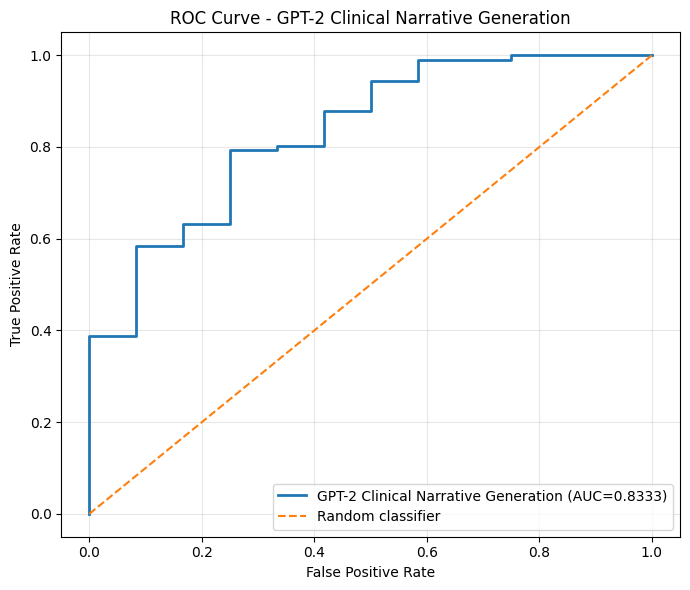


FINAL RESULTS
Dataset: HECKTOR
Model: GPT-2 Clinical Narrative Generation
Seed: 42
Training patients: 470
Test patients: 118
GPT-2 hidden dimensions: 768
GPT-2 layers: 12
GPT-2 attention heads: 12
Split: Stratified 80/20
SMOTE: No
Preprocessing: Train-only imputation
Negative class weight: 5.1087
Positive class weight: 0.5542
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 0.0001
Gradient clipping: 1.0
Epochs: 500
Batch size: 8
Max sequence length: 128
Best test loss: 0.3246
Best test BA: 0.7390
Best test AUC: 0.8333
Final AUC-checkpoint BA: 0.7020
Final AUC-checkpoint F1: 0.8788
Final AUC-checkpoint ROC-AUC: 0.8333


In [1]:
# ============================================================
# GPT-2 Clinical Narrative Generation - HECKTOR
# ============================================================

import os,random,numpy as np,pandas as pd,torch,torch.nn as nn,matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader
from transformers import GPT2Tokenizer,GPT2LMHeadModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,balanced_accuracy_score,f1_score,roc_auc_score,roc_curve
import gdown

# 1. Reproducibility
SEED=42
random.seed(SEED);np.random.seed(SEED);torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED);torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False
os.environ["PYTHONHASHSEED"]=str(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)

# 2. Load HECKTOR dataset
gdown.download(id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",output="HPV2025.xlsx",quiet=False)
df=pd.read_excel("HPV2025.xlsx")
df=df.dropna(subset=["HPV Status"]).copy()
df=df.drop(columns=["PatientID","CenterID","Task 1","Task 2","Task 3"],errors="ignore")

# 3. Convert stage variables
def stage_num(x):
    if isinstance(x,str) and x.strip().upper().startswith(("T","N","M")):
        try:return int(x.strip().upper()[1:])
        except:return np.nan
    return x

for c in ["T-stage","N-stage","M-stage"]:
    df[c]=df[c].apply(stage_num)

# 4. Select clinical variables
features=["Age","Gender","Tobacco Consumption","Alcohol Consumption","Performance Status","Relapse","RFS","Treatment","T-stage","N-stage","M-stage"]
target="HPV Status"
X=df[features].copy()
y=df[target].astype(int).copy()

print("Total patients:",len(df))
print("Class distribution:")
print(y.value_counts().sort_index())

# 5. Stratified 80/20 split BEFORE preprocessing
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=SEED,stratify=y)

print("\nTraining patients:",len(X_train))
print("Test patients:",len(X_test))
print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

# 6. Train-only imputation
cat_cols=["Gender","Tobacco Consumption","Alcohol Consumption","Performance Status","Relapse","Treatment","T-stage","N-stage","M-stage"]
num_cols=["Age","RFS"]

for c in num_cols:
    median=X_train[c].median()
    X_train[c]=X_train[c].fillna(median)
    X_test[c]=X_test[c].fillna(median)

for c in cat_cols:
    mode=X_train[c].mode()[0]
    X_train[c]=X_train[c].fillna(mode)
    X_test[c]=X_test[c].fillna(mode)

# 7. Automatic train-only class weights
class_counts=np.bincount(y_train)
class_weights=torch.tensor(len(y_train)/(len(class_counts)*class_counts),dtype=torch.float32,device=device)
print("\nClass weights:",class_weights)

# 8. Convert patient to clinical narrative
def patient_to_text(row):
    gender="male" if int(row["Gender"])==1 else "female"
    smoker="current smoker" if int(row["Tobacco Consumption"])==1 else "non-smoker"
    alcohol="consumes alcohol" if int(row["Alcohol Consumption"])==1 else "does not consume alcohol"
    relapse="has experienced disease relapse" if int(row["Relapse"])==1 else "has not experienced disease relapse"
    return (
        f"You are a clinician specialising in head and neck cancer. "
        f"Your task is to predict the patient's Human Papillomavirus (HPV) status. "
        f"The patient was diagnosed at {row['Age']:.0f} years of age and is {gender}. "
        f"The patient is a {smoker} and {alcohol}. "
        f"Performance status is {row['Performance Status']}. "
        f"The patient {relapse}. "
        f"Relapse-free survival is {row['RFS']} days. "
        f"Treatment type is {row['Treatment']}. "
        f"The tumour stage is T{int(row['T-stage'])}. "
        f"The nodal stage is N{int(row['N-stage'])}. "
        f"The metastatic stage is M{int(row['M-stage'])}. "
        f"Based on the information provided, predict the patient's HPV status. "
        f"Respond with exactly one label: HPV Positive or HPV Negative."
    )

train_texts=[patient_to_text(r) for _,r in X_train.iterrows()]
test_texts=[patient_to_text(r) for _,r in X_test.iterrows()]
train_targets=["HPV Positive" if label==1 else "HPV Negative" for label in y_train]
test_targets=["HPV Positive" if label==1 else "HPV Negative" for label in y_test]

print("\nExample clinical narrative:")
print(train_texts[0])
print("\nTarget:",train_targets[0])

# 9. GPT-2 tokenizer
MODEL_NAME="openai-community/gpt2"
tokenizer=GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token=tokenizer.eos_token
MAX_LENGTH=128

# 10. Generative dataset
class GPT2GenerationDataset(Dataset):
    def __init__(self,texts,targets,class_labels,tokenizer,max_length=128):
        self.texts=texts
        self.targets=targets
        self.class_labels=class_labels
        self.tokenizer=tokenizer
        self.max_length=max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self,idx):
        prompt=self.texts[idx]
        target=self.targets[idx]
        prompt_ids=self.tokenizer(prompt,truncation=True,max_length=self.max_length-4,add_special_tokens=False)["input_ids"]
        prompt_text=self.tokenizer.decode(prompt_ids,skip_special_tokens=True)
        full_text=prompt_text+" "+target
        full=self.tokenizer(full_text,truncation=True,max_length=self.max_length,padding="max_length",return_tensors="pt")
        input_ids=full["input_ids"].squeeze(0)
        attention_mask=full["attention_mask"].squeeze(0)
        labels=input_ids.clone()
        labels[:len(prompt_ids)]=-100
        labels[attention_mask==0]=-100
        return {
            "input_ids":input_ids,
            "attention_mask":attention_mask,
            "labels":labels,
            "class_label":torch.tensor(self.class_labels[idx],dtype=torch.long)
        }

# 11. Create datasets
train_dataset=GPT2GenerationDataset(train_texts,train_targets,y_train.to_numpy(),tokenizer,MAX_LENGTH)
test_dataset=GPT2GenerationDataset(test_texts,test_targets,y_test.to_numpy(),tokenizer,MAX_LENGTH)

# 12. DataLoaders
BATCH_SIZE=8
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

# 13. GPT-2 Small generative model
model=GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device)
model.config.pad_token_id=tokenizer.pad_token_id

print("\nGPT-2 hidden size:",model.config.n_embd)
print("GPT-2 layers:",model.config.n_layer)
print("GPT-2 attention heads:",model.config.n_head)

assert model.config.n_embd==768

# 14. Optimizer
optimizer=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)

# 15. Weighted generation loss
def weighted_generation_loss(logits,labels,class_labels):
    shift_logits=logits[...,:-1,:].contiguous()
    shift_labels=labels[...,1:].contiguous()
    loss_fct=nn.CrossEntropyLoss(reduction="none")
    token_loss=loss_fct(
        shift_logits.view(-1,shift_logits.size(-1)),
        shift_labels.view(-1)
    ).view(shift_labels.size(0),-1)
    valid_tokens=(shift_labels!=-100).float()
    example_loss=(token_loss*valid_tokens).sum(1)/valid_tokens.sum(1).clamp(min=1)
    example_weights=class_weights[class_labels]
    return (example_loss*example_weights).mean()

# 16. Continuous HPV score for BA/AUC
def get_hpv_scores(prompts,batch_size=8):
    model.eval()
    all_scores=[]
    with torch.no_grad():
        for start in range(0,len(prompts),batch_size):
            rows=[]
            for prompt in prompts[start:start+batch_size]:
                ids=tokenizer(prompt,truncation=True,max_length=MAX_LENGTH-4,add_special_tokens=False)["input_ids"]
                prompt=tokenizer.decode(ids,skip_special_tokens=True)
                rows.append((prompt,"HPV Positive",len(ids)))
                rows.append((prompt,"HPV Negative",len(ids)))
            enc=tokenizer(
                [p+" "+c for p,c,_ in rows],
                truncation=True,
                max_length=MAX_LENGTH,
                padding=True,
                return_tensors="pt"
            ).to(device)
            labels=enc["input_ids"].clone()
            for i,(_,_,n) in enumerate(rows):
                labels[i,:n]=-100
            labels[enc["attention_mask"]==0]=-100
            outputs=model(
                input_ids=enc["input_ids"],
                attention_mask=enc["attention_mask"]
            )
            logits=outputs.logits[...,:-1,:].contiguous()
            shift_labels=labels[...,1:].contiguous()
            token_loss=nn.CrossEntropyLoss(reduction="none")(
                logits.view(-1,logits.size(-1)),
                shift_labels.view(-1)
            ).view(len(rows),-1)
            valid=(shift_labels!=-100).float()
            losses=((token_loss*valid).sum(1)/valid.sum(1).clamp(min=1)).view(-1,2)
            positive_loss=losses[:,0]
            negative_loss=losses[:,1]
            scores=negative_loss-positive_loss
            all_scores.extend(scores.cpu().numpy())
    return np.array(all_scores)

# 17. Training settings
EPOCHS=500
best_test_loss=float("inf")
best_test_ba=-1
best_test_auc=-1
best_loss_path="best_model_gpt2_generation_loss.pth"
best_ba_path="best_model_gpt2_generation_ba.pth"
best_auc_path="best_model_gpt2_generation_auc.pth"

# 18. Training loop
for epoch in range(EPOCHS):
    model.train()
    total_train_loss=0.0

    for batch in train_loader:
        input_ids=batch["input_ids"].to(device)
        attention_mask=batch["attention_mask"].to(device)
        labels=batch["labels"].to(device)
        class_labels=batch["class_label"].to(device)

        optimizer.zero_grad()
        outputs=model(input_ids=input_ids,attention_mask=attention_mask)
        loss=weighted_generation_loss(outputs.logits,labels,class_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        total_train_loss+=loss.item()

    avg_train_loss=total_train_loss/len(train_loader)

    # Test loss
    model.eval()
    total_test_loss=0.0
    with torch.no_grad():
        for batch in test_loader:
            input_ids=batch["input_ids"].to(device)
            attention_mask=batch["attention_mask"].to(device)
            labels=batch["labels"].to(device)
            class_labels=batch["class_label"].to(device)
            outputs=model(input_ids=input_ids,attention_mask=attention_mask)
            loss=weighted_generation_loss(outputs.logits,labels,class_labels)
            total_test_loss+=loss.item()

    avg_test_loss=total_test_loss/len(test_loader)

    # Test BA/AUC
    auc_scores=get_hpv_scores(test_texts,BATCH_SIZE)
    test_predictions=(auc_scores>0).astype(int)
    test_ba=balanced_accuracy_score(y_test,test_predictions)
    test_auc=roc_auc_score(y_test,auc_scores)

    # Save best checkpoints
    if avg_test_loss<best_test_loss:
        best_test_loss=avg_test_loss
        torch.save(model.state_dict(),best_loss_path)

    if test_ba>best_test_ba:
        best_test_ba=test_ba
        torch.save(model.state_dict(),best_ba_path)

    if test_auc>best_test_auc:
        best_test_auc=test_auc
        torch.save(model.state_dict(),best_auc_path)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Test Loss: {avg_test_loss:.4f} | "
        f"BA: {test_ba:.4f} | "
        f"AUC: {test_auc:.4f}"
    )

# 19. Evaluate best-loss checkpoint
model.load_state_dict(torch.load(best_loss_path,map_location=device))
loss_scores=get_hpv_scores(test_texts,BATCH_SIZE)
loss_predictions=(loss_scores>0).astype(int)
loss_ba=balanced_accuracy_score(y_test,loss_predictions)
loss_f1=f1_score(y_test,loss_predictions,zero_division=0)
loss_auc=roc_auc_score(y_test,loss_scores)

print("\n===== BEST TEST LOSS CHECKPOINT =====")
print(classification_report(y_test,loss_predictions,target_names=["HPV Negative","HPV Positive"],digits=4,zero_division=0))
print(f"Balanced Accuracy: {loss_ba:.4f}")
print(f"F1 Score: {loss_f1:.4f}")
print(f"ROC-AUC: {loss_auc:.4f}")

# 20. Evaluate best-BA checkpoint
model.load_state_dict(torch.load(best_ba_path,map_location=device))
ba_scores=get_hpv_scores(test_texts,BATCH_SIZE)
ba_predictions=(ba_scores>0).astype(int)
ba_ba=balanced_accuracy_score(y_test,ba_predictions)
ba_f1=f1_score(y_test,ba_predictions,zero_division=0)
ba_auc=roc_auc_score(y_test,ba_scores)

print("\n===== BEST BALANCED ACCURACY CHECKPOINT =====")
print(classification_report(y_test,ba_predictions,target_names=["HPV Negative","HPV Positive"],digits=4,zero_division=0))
print(f"Balanced Accuracy: {ba_ba:.4f}")
print(f"F1 Score: {ba_f1:.4f}")
print(f"ROC-AUC: {ba_auc:.4f}")

# 21. Evaluate best-AUC checkpoint
model.load_state_dict(torch.load(best_auc_path,map_location=device))
auc_scores=get_hpv_scores(test_texts,BATCH_SIZE)
auc_predictions=(auc_scores>0).astype(int)
auc_ba=balanced_accuracy_score(y_test,auc_predictions)
auc_f1=f1_score(y_test,auc_predictions,zero_division=0)
auc_value=roc_auc_score(y_test,auc_scores)

print("\n===== BEST AUC CHECKPOINT =====")
print(classification_report(y_test,auc_predictions,target_names=["HPV Negative","HPV Positive"],digits=4,zero_division=0))
print(f"Balanced Accuracy: {auc_ba:.4f}")
print(f"F1 Score: {auc_f1:.4f}")
print(f"ROC-AUC: {auc_value:.4f}")

# 22. Generate HPV prediction
def generate_prediction(prompt):
    model.eval()
    encoding=tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(device)

    with torch.no_grad():
        generated_ids=model.generate(
            **encoding,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    new_tokens=generated_ids[0][encoding["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens,skip_special_tokens=True).strip()

# 23. Extract generated HPV label
def extract_hpv_label(text):
    text=text.lower()
    if "hpv positive" in text:return 1
    if "hpv negative" in text:return 0
    if "positive" in text:return 1
    if "negative" in text:return 0
    return -1

# 24. Generate predictions for test patients
generated_predictions=[]
print("\n===== GENERATED TEST PREDICTIONS =====")

for i,prompt in enumerate(test_texts):
    generated=generate_prediction(prompt)
    prediction=extract_hpv_label(generated)
    generated_predictions.append(prediction)
    print(f"Patient {i+1}/{len(test_texts)}: {generated} -> {prediction}")

generated_predictions=np.array(generated_predictions)
valid=generated_predictions!=-1
print("\nInvalid generated predictions:",np.sum(~valid))

if np.any(valid):
    y_true=np.array(y_test)[valid]
    y_pred=generated_predictions[valid]
    generated_ba=balanced_accuracy_score(y_true,y_pred)
    generated_f1=f1_score(y_true,y_pred,zero_division=0)
    print("\n===== GENERATED LABEL RESULTS =====")
    print(classification_report(y_true,y_pred,target_names=["HPV Negative","HPV Positive"],digits=4,zero_division=0))
    print(f"Balanced Accuracy: {generated_ba:.4f}")
    print(f"F1 Score: {generated_f1:.4f}")

# 25. ROC curve for best-AUC checkpoint
fpr,tpr,_=roc_curve(y_test,auc_scores)

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,linewidth=2,label=f"GPT-2 Clinical Narrative Generation (AUC={auc_value:.4f})")
plt.plot([0,1],[0,1],"--",linewidth=1.5,label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GPT-2 Clinical Narrative Generation")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 26. Final summary
print("\n"+"="*60)
print("FINAL RESULTS")
print("="*60)
print("Dataset: HECKTOR")
print("Model: GPT-2 Clinical Narrative Generation")
print(f"Seed: {SEED}")
print(f"Training patients: {len(y_train)}")
print(f"Test patients: {len(y_test)}")
print(f"GPT-2 hidden dimensions: {model.config.n_embd}")
print(f"GPT-2 layers: {model.config.n_layer}")
print(f"GPT-2 attention heads: {model.config.n_head}")
print("Split: Stratified 80/20")
print("SMOTE: No")
print("Preprocessing: Train-only imputation")
print(f"Negative class weight: {class_weights[0].item():.4f}")
print(f"Positive class weight: {class_weights[1].item():.4f}")
print("Optimizer: AdamW")
print("Learning rate: 0.001")
print("Weight decay: 0.0001")
print("Gradient clipping: 1.0")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max sequence length: {MAX_LENGTH}")
print(f"Best test loss: {best_test_loss:.4f}")
print(f"Best test BA: {best_test_ba:.4f}")
print(f"Best test AUC: {best_test_auc:.4f}")
print(f"Final AUC-checkpoint BA: {auc_ba:.4f}")
print(f"Final AUC-checkpoint F1: {auc_f1:.4f}")
print(f"Final AUC-checkpoint ROC-AUC: {auc_value:.4f}")
print("="*60)